# Intro

The features that we have available to us
1. m/z
2. adducts
3. mqns (42): "c", "f", "cl", "br", "i", "s", "p", "an", "cn", "ao", "co",
    "hac", "hbam", "hba", "hbdm", "hbd", "neg", "pos", "asb", "adb",
    "atb", "csb", "cdb", "ctb", "rbc", "asv", "adv", "atv", "aqv",
    "cdv", "ctv", "cqv", "r3", "r4", "r5", "r6", "r7", "r8", "r9",
    "rg10", "afr", "bfr"
4. Fingerprints
5. Polarization


This notebook will focus on solving this problem through a Node-Level approach. Only one graph will exist and each node is a distinct molecule and each edge is a similarity embedding from one node to another.

Our goal is to predict CCS on the node level. By aggregating similar values seen through its nearest similar neighbours

# Loading in C3S

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import copy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Load Data
import pandas as pd 

In [ ]:
c3s_result = pd.DataFrame()

In [50]:
master_df = pd.read_csv("C3S_GHR_Cleaned_2025_05_09.csv")
print(master_df.shape)
master_df.head(1)

(11543, 11)


,Unnamed: 0,g_id,name,mz,adduct,ccs,src_tag,smi,chem_class_label,ccs_type,calc_mz
0,5095,CCSBASE_e248b21d7739b60346d44984ba6819d5,decabromobiphenyl (pbb 209),933.183371,[M]+,199.7,mull_1223,Brc1c(Br)c(Br)c(-c2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,small molecule,TIMS,933.182822


In [ ]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, AllChem

# --- load your data ---
master_df["mol"] = master_df["smi"].apply(Chem.MolFromSmiles)

# --- compute raw MQN vectors ---
mqn_list = master_df["mol"].apply(lambda m: rdMolDescriptors.MQNs_(m) 
                                  if m is not None else [None]*42)
mqn_df = pd.DataFrame(mqn_list.tolist(), index=master_result.index)

# --- give them human‐readable names ---
mqn_names = [
    # Category 1: Atom counts
    "c","f","cl","br","i","s","p",
    "an","cn","ao","co","hac",
    # Category 2: Bond counts
    "asb","adb","atb","csb","cdb","ctb","rbc",
    # Category 3: Polarity counts
    "hbam","hba","hbdm","hbd","negc","posc",
    # Category 4: Topology counts
    "asv","adv","atv","aqv","cdv","ctv","cqv",
    "r3","r4","r5","r6","r7","r8","r9","rg10","afrc","bfrc"
]
mqn_df.columns = mqn_names

# --- compute 1024‐bit Morgan fingerprints as before ---
def mol_to_fp_bits(mol, radius=2, n_bits=1024):
    if mol is None:
        return [None]*n_bits
    return list(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))

fp_bits = master_df["mol"].apply(mol_to_fp_bits)
fp_df = pd.DataFrame(
    fp_bits.tolist(),
    columns=[f"fp_{i}" for i in range(1024)],
    index=master_df.index
)

In [55]:
print(mqn_df.columns)

Index(['c', 'f', 'cl', 'br', 'i', 's', 'p', 'an', 'cn', 'ao', 'co', 'hac',
       'asb', 'adb', 'atb', 'csb', 'cdb', 'ctb', 'rbc', 'hbam', 'hba', 'hbdm',
       'hbd', 'negc', 'posc', 'asv', 'adv', 'atv', 'aqv', 'cdv', 'ctv', 'cqv',
       'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'rg10', 'afrc', 'bfrc'],
      dtype='object')


In [57]:
# --- assemble your final c3s_df ---
c3s_df = pd.concat(
    [master_df.drop(columns="mol"), mqn_df[["adv", "hac", "hbam", "c", "asb"]], fp_df],
    axis=1
)

In [58]:
print(c3s_df.shape)
c3s_df.head(1)

(11543, 1040)


,Unnamed: 0,g_id,name,mz,adduct,ccs,src_tag,smi,chem_class_label,ccs_type,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,5095,CCSBASE_e248b21d7739b60346d44984ba6819d5,decabromobiphenyl (pbb 209),933.183371,[M]+,199.7,mull_1223,Brc1c(Br)c(Br)c(-c2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,small molecule,TIMS,...,0,0,0,0,0,1,0,0,0,0


In [59]:
c3s_df.to_csv("cleaned.csv", index=False)

## Adduct Encoding

In [60]:
from sklearn.preprocessing import OneHotEncoder

In [61]:
adduct_groups = [
    "[M+H]+", "[M+Na]+", "[M-H]-", "[M+NH4]+", "[M+K]+",
    "[M+H-H2O]+", "[M+HCOO]-", "[M+CH3COO]-", "[M+Na-2H]-"
]

# Create OneHotEncoder
adduct_encoding = OneHotEncoder(
    sparse_output=False,
    categories='auto', #encodes every other adducts larger than 5
    handle_unknown="infrequent_if_exist",
    min_frequency=5 #needs to be above 5 data samples to be encoded. if below gets grouped to others
)

adduct_encoded = adduct_encoding.fit_transform(c3s_df[['adduct']])
adduct_encoded_df = pd.DataFrame(adduct_encoded)
print(adduct_encoded_df.shape)
print(adduct_encoded_df.head())

# Concatenate the original DataFrame with the one-hot encoded DataFrame
adduct_encoded_df.head()
c3s_df = c3s_df.join(adduct_encoded_df.set_index(c3s_df.index))
c3s_df.head(1)

(11543, 10)
     0    1    2    3    4    5    6    7    8    9
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0


,Unnamed: 0,g_id,name,mz,adduct,ccs,src_tag,smi,chem_class_label,ccs_type,...,0,1,2,3,4,5,6,7,8,9
0,5095,CCSBASE_e248b21d7739b60346d44984ba6819d5,decabromobiphenyl (pbb 209),933.183371,[M]+,199.7,mull_1223,Brc1c(Br)c(Br)c(-c2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,small molecule,TIMS,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Final Dataset

In [77]:
c3s_df_final = c3s_df.copy()
c3s_df_final = c3s_df_final.drop(columns=['g_id', 'Unnamed: 0', 'adduct', 'name', "smi", 'chem_class_label', 'src_tag', 'ccs_type', 'calc_mz'], axis=1)

print(c3s_df_final.head(1))
print(c3s_df_final.columns)

           mz    ccs  adv  hac  hbam   c  asb  fp_0  fp_1  fp_2  ...    0   
0  933.183371  199.7    0   22     0  12   11     0     0     0  ...  0.0  \

     1    2    3    4    5    6    7    8    9  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  

[1 rows x 1041 columns]
Index([  'mz',  'ccs',  'adv',  'hac', 'hbam',    'c',  'asb', 'fp_0', 'fp_1',
       'fp_2',
       ...
            0,      1,      2,      3,      4,      5,      6,      7,      8,
            9],
      dtype='object', length=1041)


# Building GNN - Train Set



In [78]:
c3s_df_final = c3s_df_final.dropna()
print(c3s_df_final.shape)
print(c3s_df_final.columns)

(11543, 1041)
Index([  'mz',  'ccs',  'adv',  'hac', 'hbam',    'c',  'asb', 'fp_0', 'fp_1',
       'fp_2',
       ...
            0,      1,      2,      3,      4,      5,      6,      7,      8,
            9],
      dtype='object', length=1041)


## Building Features

In [79]:
use_subset = False

if use_subset:
  c3s_df_final = c3s_df_final.sample(n=200, random_state=42)

print(c3s_df_final.shape)

(11543, 1041)


In [80]:
c3s_target_df = c3s_df_final["ccs"]
c3s_featuers_df = c3s_df_final.drop("ccs", axis=1)


#c3s_df now has the full features we need for everything. Now train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    c3s_featuers_df, c3s_target_df, test_size=0.2, random_state=42
)

print("training and validation set")
print(X_train.shape)
print(y_train.shape)

print("test set")
print(X_test.shape)
print(y_test.shape)

training and validation set
(9234, 1040)
(9234,)
test set
(2309, 1040)
(2309,)


## Building Edges Knn

In [81]:
import torch
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F
from torch.nn import Linear
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [82]:
X_train_tensor = torch.tensor(X_train.values.astype(np.float32), dtype=torch.float)
y_train_tensor = torch.tensor(y_train.values.astype(np.float32), dtype=torch.float)

X_test_tensor = torch.tensor(X_test.values.astype(np.float32), dtype=torch.float)
y_test_tensor = torch.tensor(y_test.values.astype(np.float32), dtype=torch.float)

In [83]:
from sklearn.neighbors import NearestNeighbors

if "g_id" in fp_df.columns:
    fp_df = fp_df.drop(columns=["g_id"])


#1. Building Graph for Train Set
knn = NearestNeighbors(n_neighbors=5, metric='jaccard') #use jaccard similarity to find 5 nearest neighbours
knn.fit(X_train[fp_df.columns]) # Fit the nearest neighbors estimator from the training dataset based on fingerprints

# Compute the (weighted) graph of k-Neighbors for points in X. returns a list of edges
knn_graph_train = knn.kneighbors_graph(X_train[fp_df.columns], mode='connectivity').tocoo()
edge_index_train = torch.tensor(np.array([knn_graph_train.row, knn_graph_train.col]), dtype=torch.long)


#2. Building graph for Test Set
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

knn = NearestNeighbors(n_neighbors=5, metric='jaccard')
knn.fit(X_test[fp_df.columns])  # must match column structure

knn_graph_test = knn.kneighbors_graph(X_test[fp_df.columns], mode='connectivity').tocoo()
edge_index_test = torch.tensor(np.array([knn_graph_test.row, knn_graph_test.col]), dtype=torch.long)

/opt/miniconda3/envs/database_clean/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/opt/miniconda3/envs/database_clean/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [84]:
print(edge_index_train.shape)
print("\n")
print(edge_index_test.shape)

torch.Size([2, 46170])


torch.Size([2, 11545])


## So right now we have the following variables for training:
1. Pandas Dataframes: X_train, X_test, y_train, y_test
2. Tensors: X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor
3. Edge List: edge_index_train, edge_index_test

In [85]:
def train(model, data, num_epochs, learning_rate):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    criterion = nn.MSELoss()

    train_history = []
    val_history = []

    for epoch in range(num_epochs):
        # --- Train phase ---
        model.train()
        optimizer.zero_grad()
        out = model(data) #the predicted data

        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()

        optimizer.step()
        train_loss = loss.item() # Returns Mean Squared Error (MSE) — not the sum of differences.
        train_history.append(train_loss)

        # --- Val phase ---
        model.eval()
        with torch.no_grad():
            val_out = model(data)
            val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask])
            val_loss_item = val_loss.item()
            val_history.append(val_loss_item)

            # --- True MRE calculation --- (not MRE Loss)
            abs_y_error_train = torch.abs(out[data.train_mask] - data.y[data.train_mask])
            mre_train = torch.mean(100. * abs_y_error_train / data.y[data.train_mask])

            abs_y_error_val = torch.abs(val_out[data.val_mask] - data.y[data.val_mask])
            mre_val = torch.mean(100. * abs_y_error_val / data.y[data.val_mask])

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Val Loss: {val_loss_item:.4f}")
        print(f"True MRE Train: {mre_train:.4f}, True MRE Val: {mre_val:.4f}")

    return train_history, val_history, model


# Example plot function to visualize the loss histories
def plot_history(histories):
    for h in histories:
        epochs = range(1, len(h['train_loss']) + 1)
        plt.plot(epochs, h['train_loss'], label=f"{h['name']} Train Loss")
        plt.plot(epochs, h['val_loss'], label=f"{h['name']} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [86]:
class GNN_NodeLevel(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, hidden3):
        """
        GNN for node-level regression (CCS prediction per molecule node).
        """
        super(GNN_NodeLevel, self).__init__()
        torch.manual_seed(1234)

        # self.dropout_rates = [0.5, 0.3]

        self.conv1 = SAGEConv(input_dim, hidden1, aggr='mean')
        self.bn1 = nn.BatchNorm1d(hidden1)

        self.conv2 = SAGEConv(hidden1, hidden2, aggr='mean')
        self.bn2 = nn.BatchNorm1d(hidden2)

        self.conv3 = SAGEConv(hidden2, hidden3, aggr='mean')
        self.bn3 = nn.BatchNorm1d(hidden3)

        self.output = Linear(hidden3, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        # x = F.dropout(x, p=self.dropout_rates[0], training=self.training)

        # Layer 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        # x = F.dropout(x, p=self.dropout_rates[1], training=self.training)

        x = self.output(x)
        return x.squeeze()  # transforms the data into: [num_nodes, 1]

In [87]:
# Training Node Level Model
from sklearn.model_selection import KFold
from itertools import product
from torch_geometric.utils import subgraph
from torch_geometric.data import Data
import time

data_train_val = Data(
    x=X_train_tensor,
    y=y_train_tensor,
    edge_index=edge_index_train
).to(device)

data_test = Data(
    x=X_test_tensor,
    y=y_test_tensor,
    edge_index=edge_index_test
).to(device)


learning_rates = [0.001, 0.01, 0.1]
hidden_layer_configs = [
    (520, 260, 130),
    (128, 64, 32),
    (256, 128, 64),
]

grid = list(product(learning_rates, hidden_layer_configs))


=== Grid 1/9 | LR=0.001, Hidden=(520,260,130) ===
Fold 1/3
Epoch 1/120 | Train Loss: 48306.5508, Val Loss: 48394.7695
True MRE Train: 99.9338, True MRE Val: 99.1090
Epoch 2/120 | Train Loss: 48145.7461, Val Loss: 48072.7188
True MRE Train: 100.0164, True MRE Val: 98.8202
Epoch 3/120 | Train Loss: 48061.8281, Val Loss: 47793.9336
True MRE Train: 100.0300, True MRE Val: 98.5859
Epoch 4/120 | Train Loss: 47990.5195, Val Loss: 47628.1211
True MRE Train: 100.0139, True MRE Val: 98.4755
Epoch 5/120 | Train Loss: 47939.1445, Val Loss: 47561.9531
True MRE Train: 99.9899, True MRE Val: 98.4744
Epoch 6/120 | Train Loss: 47898.0742, Val Loss: 47575.1484
True MRE Train: 99.9612, True MRE Val: 98.5509
Epoch 7/120 | Train Loss: 47859.8633, Val Loss: 47634.7852
True MRE Train: 99.9261, True MRE Val: 98.6645
Epoch 8/120 | Train Loss: 47822.2656, Val Loss: 47704.5352
True MRE Train: 99.8906, True MRE Val: 98.7820
Epoch 9/120 | Train Loss: 47786.0703, Val Loss: 47763.9961
True MRE Train: 99.8562, True 

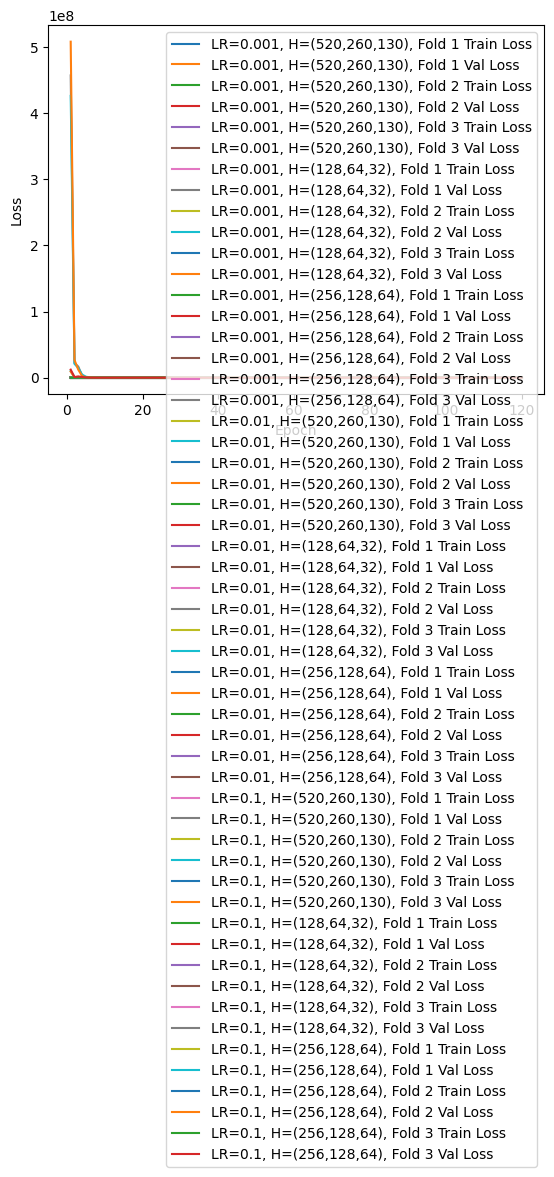

In [88]:
# Track best model
best_model = None
best_params = None

best_val_mre = float('inf')
best_train_mre = float('inf')

# Store all histories
all_histories = []

# Loop over grid of hyperparameters
for i, (lr, (h1, h2, h3)) in enumerate(grid):
    print(f"\n=== Grid {i+1}/{len(grid)} | LR={lr}, Hidden=({h1},{h2},{h3}) ===")

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_train_mres = []
    fold_val_mres = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(data_train_val.x)):
        print(f"Fold {fold+1}/{kf.get_n_splits()}")

        # Combine all indices and build subgraph
        all_idx = torch.tensor(train_idx.tolist() + val_idx.tolist(), dtype=torch.long)
        edge_index_sub, _ = subgraph(subset=all_idx, edge_index=data_train_val.edge_index, relabel_nodes=True)

        x_sub = data_train_val.x[all_idx] #grabs features from masked index
        y_sub = data_train_val.y[all_idx] #grabs target from masked target

        train_idx_new = torch.arange(len(train_idx))
        val_idx_new = torch.arange(len(train_idx), len(all_idx))

        data_fold = Data(x=x_sub, y=y_sub, edge_index=edge_index_sub) #creates a new data fold with the index masking
        mask = torch.zeros(len(all_idx), dtype=torch.bool)

        data_fold.train_mask = mask.clone()
        data_fold.train_mask[train_idx_new] = True #activate the index for train feeding
        data_fold.val_mask = mask.clone()
        data_fold.val_mask[val_idx_new] = True

        # Train the model
        model = GNN_NodeLevel(input_dim=data_fold.num_features, hidden1=h1, hidden2=h2, hidden3=h3).to(device)
        data_fold = data_fold.to(device)
        train_hist, val_hist, trained_model = train(model, data_fold, num_epochs=120, learning_rate=lr)

        # Inference for final fold MREs
        model.eval()
        with torch.no_grad():
            preds = model(data_fold)
            y_true = data_fold.y

            abs_y_error_train = torch.abs(preds[data_fold.train_mask] - data_fold.y[data_fold.train_mask])
            train_mre = torch.mean(100. * abs_y_error_train / data_fold.y[data_fold.train_mask])

            abs_y_error_val = torch.abs(preds[data_fold.val_mask] - data_fold.y[data_fold.val_mask])
            val_mre = torch.mean(100. * abs_y_error_val / data_fold.y[data_fold.val_mask])

        fold_train_mres.append(train_mre)
        fold_val_mres.append(val_mre)

        # Save history for plotting
        all_histories.append({
            'name': f'LR={lr}, H=({h1},{h2},{h3}), Fold {fold+1}',
            'train_loss': train_hist,
            'val_loss': val_hist
        })

    # Average MREs across folds of this setting
    avg_train_mre = sum(fold_train_mres) / len(fold_train_mres)
    avg_val_mre = sum(fold_val_mres) / len(fold_val_mres)
    print(f"Avg Train MRE: {avg_train_mre:.4f}, Avg Val MRE: {avg_val_mre:.4f}")

    if avg_val_mre < best_val_mre:
        best_val_mre = avg_val_mre
        best_train_mre = avg_train_mre
        best_model = trained_model
        best_params = {'lr': lr, 'hidden': (h1, h2, h3)}


# Final best config
print(f"\n✅ Best Config: LR={best_params['lr']}, Hidden={best_params['hidden']}")
print(f"📉 Best Train MRE%: {best_train_mre:.4f}, Best Val MRE: {best_val_mre:.4f}")

# Plot all histories
plot_history(all_histories)

# Retrain on Full Train Set

In [89]:
print(best_params)
print(best_model)

{'lr': 0.1, 'hidden': (520, 260, 130)}
GNN_NodeLevel(
  (conv1): SAGEConv(1040, 520, aggr=mean)
  (bn1): BatchNorm1d(520, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SAGEConv(520, 260, aggr=mean)
  (bn2): BatchNorm1d(260, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): SAGEConv(260, 130, aggr=mean)
  (bn3): BatchNorm1d(130, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=130, out_features=1, bias=True)
)


In [90]:
# Create full train mask (all nodes included)
data_train_val.train_mask = torch.ones(data_train_val.num_nodes, dtype=torch.bool)
data_train_val.val_mask = torch.zeros(data_train_val.num_nodes, dtype=torch.bool)  # no val phase now

# Build model with best hyperparameters
best_gnn_model = GNN_NodeLevel(
    input_dim=data_train_val.num_features,
    hidden1=best_params['hidden'][0],
    hidden2=best_params['hidden'][1],
    hidden3=best_params['hidden'][2]
).to(device)

# Retrain model on all training data
train_hist, _, best_gnn_model = train(
    best_gnn_model,
    data_train_val,
    num_epochs=350,
    learning_rate=best_params['lr']
)

Epoch 1/350 | Train Loss: 48601.3438, Val Loss: nan
True MRE Train: 99.9323, True MRE Val: nan
Epoch 2/350 | Train Loss: 45967.2148, Val Loss: nan
True MRE Train: 97.5960, True MRE Val: nan
Epoch 3/350 | Train Loss: 42371.2734, Val Loss: nan
True MRE Train: 94.5336, True MRE Val: nan
Epoch 4/350 | Train Loss: 37845.5781, Val Loss: nan
True MRE Train: 90.6601, True MRE Val: nan
Epoch 5/350 | Train Loss: 32820.7773, Val Loss: nan
True MRE Train: 85.8446, True MRE Val: nan
Epoch 6/350 | Train Loss: 27288.9961, Val Loss: nan
True MRE Train: 79.4467, True MRE Val: nan
Epoch 7/350 | Train Loss: 21548.4902, Val Loss: nan
True MRE Train: 71.3288, True MRE Val: nan
Epoch 8/350 | Train Loss: 15884.1377, Val Loss: nan
True MRE Train: 61.8723, True MRE Val: nan
Epoch 9/350 | Train Loss: 10651.0010, Val Loss: nan
True MRE Train: 51.0193, True MRE Val: nan
Epoch 10/350 | Train Loss: 6182.5278, Val Loss: nan
True MRE Train: 38.4264, True MRE Val: nan
Epoch 11/350 | Train Loss: 2852.4451, Val Loss: na

In [91]:
best_gnn_model.eval()
with torch.no_grad(): # disables gradient calculation -> no intermediate tensors will be saved for backpropagation
    test_preds = best_gnn_model(data_test)
    test_mre = (100 * torch.abs(test_preds - data_test.y) / (data_test.y)).mean()

print(f"\n🏁 Final Test MRE using Best Config: {test_mre:.4f}")


🏁 Final Test MRE using Best Config: 2.8349


In [92]:
with torch.no_grad():
    y_pred_train = best_gnn_model(data_train_val) #predicted values from train
    y_pred_test = best_gnn_model(data_test) #predicted values from test

#convert to numpy
y_train_np = data_train_val.y.detach().cpu().numpy()
y_test_np = data_test.y.detach().cpu().numpy()
y_pred_train_np = y_pred_train.detach().cpu().numpy()
y_pred_test_np = y_pred_test.detach().cpu().numpy()

In [99]:
# 1) Move to cpu & numpy
ori_X = data_test.x.cpu().numpy()            # shape [N, F]
ori_Y = data_test.y.cpu().numpy()            # shape [N, F]
ori_edge = data_test.edge_index.cpu().numpy()            # shape [N, F]
preds = test_preds.cpu().detach().numpy()  # shape [N]

# 2) Build DataFrame
#    name the feature columns f0, f1, …, f{F-1}
feature_cols = [X_train.columns]
df = pd.DataFrame(ori_X, columns=feature_cols)

#    add the predictions as a new column
df["actual_ccs"] = ori_Y
df["predicted_ccs"] = preds
# df["edge_index"] = ori_edge

# 3) Save to CSV
df.to_csv("node_predictions.csv", index=False)


In [93]:
from typing import Dict, List
from matplotlib.gridspec import GridSpec
from numpy import typing as npt
from sklearn.metrics import r2_score, mean_squared_error

def compute_metrics(y: npt.NDArray[np.float64],
                    y_pred: npt.NDArray[np.float64]
                    ) -> Dict[str, float | List[float]] :
    """
    compute a standard array of metrics between a set of predicted and reference values

    - R-squared (R2)
    - root mean squared error (RMSE)
    - mean absolute error (MAE)
    - median absolute erre (MDAE)
    - mean relative error % (MRE)
    - median relative error % (MDRE)
    - cumulative error distribution at the <1, <3, <5, and <10% levels (CE135A)

    Parameters
    ----------
    y : ``numpy.ndarray(float)``
    y_pred : ``numpy.ndarray(float)``
        arrays of reference and predicted values

    Returns
    -------
    summary : ``dict(...)``
        dict with set of metrics
    """
    abs_y_err = np.abs(y_pred - y)
    r2 = r2_score(y, y_pred)
    mae = np.mean(abs_y_err)
    mdae = np.median(abs_y_err)
    mre = np.mean(100. * abs_y_err / y)
    mdre = np.median(100. * abs_y_err / y)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    y_err_percent = 100. * abs_y_err / y
    cum_err = np.cumsum(np.histogram(y_err_percent, [_ for _ in range(101)])[0])
    cum_err = 100. * cum_err / np.sum(cum_err)
    ce1, ce3, ce5, ceA = cum_err[0], cum_err[2], cum_err[4], cum_err[9]
    return {
        'R2': r2, 'MAE': mae, 'MDAE': mdae, 'MRE': mre, 'MDRE': mdre,
        'RMSE': rmse, 'CE135A': [ce1, ce3, ce5, ceA]
    }


def compute_metrics_train_test(y_train: npt.NDArray[np.float64],
                               y_test: npt.NDArray[np.float64],
                               y_pred_train: npt.NDArray[np.float64],
                               y_pred_test: npt.NDArray[np.float64]
                               ) -> Dict[str, Dict[str, float | List[float]]] :
    """
    computes a standard set of performance metrics from separate predictions
    for a training and test dataset
    - training and test set R-squared (R2)
    - training and test set root mean squared error (RMSE)
    - training and test set mean absolute error (MAE)
    - training and test set median absolute error (MDAE)
    - training and test set mean relative error (MRE)
    - training and test set median relative error (MDRE)
    - cumulative error distribution at the <1, <3, <5, and <10% levels
        for training and test set (CE135A)

    Parameters
    ----------
    y_train : ``numpy.ndarray(float)``
    y_test : ``numpy.ndarray(float)``
    y_pred_train : ``numpy.ndarray(float)``
    y_pred_test : ``numpy.ndarray(float)``
        arrays of reference and predicted values for training and test datasets

    Returns
    -------
    summary : ``dict(...)``
        dict with set of metrics for training and test datasets
    """
    summary = {}
    for y, y_pred, lbl in [(y_train, y_pred_train, "train"), (y_test, y_pred_test, "test")]:
        # compute metrics
        summary[lbl] = compute_metrics(y, y_pred)
    return summary

def train_test_summary_figure(summary: Dict[str, Dict[str, float | List[float]]],
                              fig_name: str,
                              r2_range=[0.95, 1.]):
    """
    produces a summary figure displaying the results from `compute_metrics_train_test`

    Parameters
    ----------
    summary : ``dict(...)``
        summary dict returned from `compute_metrics_train_test`
    fig_name : ``str``
        file name to save the generated plot under
    r2_range : ``list(float))``, default=[0.95, 1.]]
        lower and upper bounds of R-squared y axis
    """
    fig = plt.figure(figsize=(5, 3))
    gs = GridSpec(1, 4, figure=fig, width_ratios=[1.2, 3, 2, 5])

    # R-squared
    ax1 = fig.add_subplot(gs[0])
    rsq_trn = summary['train']['R2']
    rsq_tst = summary['test']['R2']
    w1 = 0.15
    ax1.bar([1 - w1 / 2, 1 + w1 / 2], [rsq_trn, rsq_tst], color=['b', 'r'], width=w1)
    for d in ['top', 'right']:
        ax1.spines[d].set_visible(False)
    ax1.set_xticks([])
    ax1.set_ylabel(r'R$^2$')
    ax1.set_ylim(r2_range)
    ax1.set_xlim([0.75, 1.25])

    # MAE, MDAE and RMSE
    ax2 = fig.add_subplot(gs[1])
    mae_trn = summary['train']['MAE']
    mae_tst = summary['test']['MAE']
    mdae_trn = summary['train']['MDAE']
    mdae_tst = summary['test']['MDAE']
    mse_trn = summary['train']['RMSE']
    mse_tst = summary['test']['RMSE']
    ax2.bar([0.875, 1.125], [mae_trn, mae_tst], color=['b', 'r'], width=0.25)
    ax2.bar([1.875, 2.125], [mdae_trn, mdae_tst], color=['b', 'r'], width=0.25)
    ax2.bar([2.875, 3.125], [mse_trn, mse_tst], color=['b', 'r'], width=0.25)
    for d in ['top', 'right']:
        ax2.spines[d].set_visible(False)
    ax2.set_xticks([1, 2, 3])
    ax2.set_xticklabels(['MAE', 'MDAE', 'RMSE'], rotation='vertical')
    ax2.set_ylabel(r'CCS (Å$^2$)')

    # CE135A
    ax3 = fig.add_subplot(gs[3])
    x1 = [_ - 0.125 for _ in range(1, 5)]
    y1 = [100. * summary['train']['CE135A'][i] for i in range(4)]
    x2 = [_ + 0.125 for _ in range(1, 5)]
    y2 = [100. * summary['test']['CE135A'][i] for i in range(4)]
    ax3.bar(x1, y1, color='b', width=0.25)
    ax3.bar(x2, y2, color='r', width=0.25)
    for d in ['top', 'right']:
        ax3.spines[d].set_visible(False)
    ax3.set_xlabel('pred. error (%)')
    ax3.set_xticks([1, 2, 3, 4])
    ax3.set_xticklabels(['<1', '<3', '<5', '<10'])
    ax3.set_ylabel('proportion (%)')
    # between axes 2 and 3

    # MRE, MDRE
    ax23 = fig.add_subplot(gs[2])
    mre_trn = summary['train']['MRE']
    mre_tst = summary['test']['MRE']
    mdre_trn = summary['train']['MDRE']
    mdre_tst = summary['test']['MDRE']
    w23 = 0.25
    ax23.bar([1 - w23 / 2, 1 + w23 / 2], [mre_trn, mre_tst], color=['b', 'r'], width=w23)
    ax23.bar([2 - w23 / 2, 2 + w23 / 2], [mdre_trn, mdre_tst], color=['b', 'r'], width=w23)
    for d in ['top', 'right']:
        ax23.spines[d].set_visible(False)
    ax23.set_xticks([1, 2])
    ax23.set_xticklabels(['MRE', 'MDRE'], rotation='vertical')
    ax23.set_ylabel('%')
    plt.tight_layout()
    plt.savefig(fig_name, dpi=400, bbox_inches='tight')

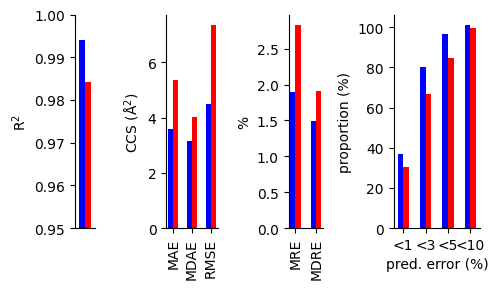

In [94]:
summary_new = compute_metrics_train_test(y_train_np, y_test_np, y_pred_train_np, y_pred_test_np)
train_test_summary_figure(summary_new, "metrics_gnn.png")

In [95]:
for key, metrics_dict in summary_new.items():
    print(key)  # This prints "train" or "test"
    for metric_name, value in metrics_dict.items():
        print(f"{metric_name}: {value}\n")

train
R2: 0.9940749469733805

MAE: 3.579420804977417

MDAE: 3.1400604248046875

MRE: 1.9010173082351685

MDRE: 1.4921033382415771

RMSE: 4.507013320922852

CE135A: [0.36862177208736613, 0.8010793860771941, 0.9643497149361586, 1.0126935538984363]

test
R2: 0.9842531406370724

MAE: 5.362405776977539

MDAE: 4.011566162109375

MRE: 2.8349244594573975

MDRE: 1.9089797735214233

RMSE: 7.368457317352295

CE135A: [0.30518233313668, 0.6698042485993994, 0.8467922586597705, 0.9958347934474514]



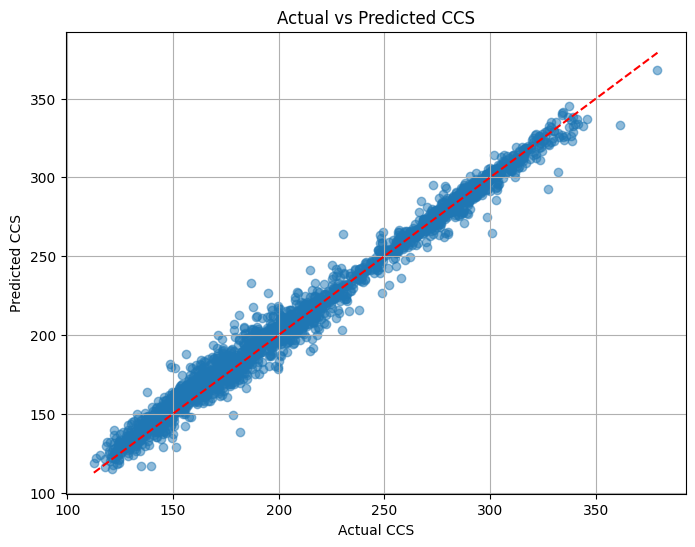

In [100]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

result = pd.read_csv("node_predictions.csv")

actual = result["actual_ccs"]
predicted = result["predicted_ccs"]

plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, alpha=0.5)
plt.plot([min(actual), max(actual)], [min(actual), max(actual)], 'r--')  # Diagonal line
plt.xlabel("Actual CCS")
plt.ylabel("Predicted CCS")
plt.title("Actual vs Predicted CCS")
plt.grid() 
plt.show()

In [129]:
result["difference"] = result["predicted_ccs"] - result["actual_ccs"]
result["abs_difference"] = result["difference"].abs()
result["percent_difference"] = (result["abs_difference"] / result["actual_ccs"]) * 100

result["abs_difference"].describe()
result["percent_difference"].describe()

result_sorted = result.sort_values(by="percent_difference", ascending=False)
result_sorted.head(20)

,mz,adv,hac,hbam,c,asb,fp_0,fp_1,fp_2,fp_3,...,5,6,7,8,9,actual_ccs,predicted_ccs,difference,abs_difference,percent_difference
873,333.2400,9.0,22.0,6.0,19.0,18.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,187.00000,233.17311,46.17311,46.17311,24.691503
1330,179.0070,0.0,11.0,10.0,5.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,181.86667,138.40459,-43.46208,43.46208,23.897771
529,365.0322,3.0,22.0,14.0,12.0,9.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,148.70000,181.75826,33.05826,33.05826,22.231513
324,365.0532,3.0,23.0,16.0,12.0,10.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,148.90000,179.96922,31.06922,31.06922,20.865829
791,253.3473,8.0,17.0,6.0,10.0,10.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,156.10000,188.03667,31.93667,31.93667,20.459110
1783,279.8972,1.0,11.0,3.0,7.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,137.60000,164.11790,26.51790,26.51790,19.271730
256,330.9597,4.0,18.0,22.0,5.0,14.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,150.90128,178.79976,27.89848,27.89848,18.487901
416,416.0815,4.0,28.0,7.0,22.0,12.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,181.40000,212.85527,31.45527,31.45527,17.340281
144,381.0950,4.0,26.0,14.0,19.0,10.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,171.50000,199.79526,28.29526,28.29526,16.498694
2265,665.2146,7.0,45.0,42.0,24.0,24.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,194.74000,226.65088,31.91088,31.91088,16.386402


In [131]:
# print([c3s_df.columns])

# list your join‐keys
keys = ["mz", "adv", "hac", "hbam", "c", "asb"]

# (optional) if mz is float, round to avoid tiny mismatches:
result_sorted["mz"] = result_sorted["mz"].round(4)
c3s_df["mz"]  = c3s_df["mz"].round(4)

# merge on all six columns
merged_df = pd.merge(
    result_sorted,
    c3s_df,
    on=keys,
    how="inner"    # or "left", "outer" depending on which rows you want kept
)
print(f"Merged {len(merged_df)} rows based on {keys}")
merged_df = merged_df.drop(columns=fp_df.columns, axis=1)
merged_df.to_csv("merged_results.csv", index=False)


Merged 2984 rows based on ['mz', 'adv', 'hac', 'hbam', 'c', 'asb']


KeyError: "['fp_0', 'fp_1', 'fp_2', 'fp_3', 'fp_4', 'fp_5', 'fp_6', 'fp_7', 'fp_8', 'fp_9', 'fp_10', 'fp_11', 'fp_12', 'fp_13', 'fp_14', 'fp_15', 'fp_16', 'fp_17', 'fp_18', 'fp_19', 'fp_20', 'fp_21', 'fp_22', 'fp_23', 'fp_24', 'fp_25', 'fp_26', 'fp_27', 'fp_28', 'fp_29', 'fp_30', 'fp_31', 'fp_32', 'fp_33', 'fp_34', 'fp_35', 'fp_36', 'fp_37', 'fp_38', 'fp_39', 'fp_40', 'fp_41', 'fp_42', 'fp_43', 'fp_44', 'fp_45', 'fp_46', 'fp_47', 'fp_48', 'fp_49', 'fp_50', 'fp_51', 'fp_52', 'fp_53', 'fp_54', 'fp_55', 'fp_56', 'fp_57', 'fp_58', 'fp_59', 'fp_60', 'fp_61', 'fp_62', 'fp_63', 'fp_64', 'fp_65', 'fp_66', 'fp_67', 'fp_68', 'fp_69', 'fp_70', 'fp_71', 'fp_72', 'fp_73', 'fp_74', 'fp_75', 'fp_76', 'fp_77', 'fp_78', 'fp_79', 'fp_80', 'fp_81', 'fp_82', 'fp_83', 'fp_84', 'fp_85', 'fp_86', 'fp_87', 'fp_88', 'fp_89', 'fp_90', 'fp_91', 'fp_92', 'fp_93', 'fp_94', 'fp_95', 'fp_96', 'fp_97', 'fp_98', 'fp_99', 'fp_100', 'fp_101', 'fp_102', 'fp_103', 'fp_104', 'fp_105', 'fp_106', 'fp_107', 'fp_108', 'fp_109'

In [111]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

def plot_smiles(smiles: str, img_size: tuple = (300, 300)):
    """
    Convert a SMILES string to an RDKit molecule and plot it.

    Args:
        smiles: SMILES string, e.g. "CCO" for ethanol.
        img_size: pixel size of the drawing (width, height).
    """
    # 1) Parse SMILES
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    
    # 2) Draw to PIL image
    img = Draw.MolToImage(mol, size=img_size)
    
    # 3) Display with matplotlib
    plt.figure(figsize=(img_size[0]/100, img_size[1]/100))
    plt.imshow(img)
    plt.axis('off')
    plt.show()



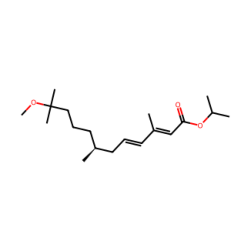

In [132]:
plot_smiles("COC(C)(C)CCC[C@H](C)C/C=C/C(C)=C/C(=O)OC(C)C")  